In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import sunpy.visualization.colormaps as sunpycm
from sunpy.visualization.colormaps import color_tables

from loguru import logger as lgr_logger
from omegaconf import OmegaConf

from sdofmv2.core import MAE, SDOMLDataModule
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

In [3]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

In [4]:
cache_dir = "../../../assets/cache/ALL/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

2026-05-27 02:13:04.079 | INFO     | sdofmv2.core.datamodule:setup:639 - Train dataloader is ready!
2026-05-27 02:13:04.080 | INFO     | sdofmv2.core.datamodule:setup:640 - Dataset size: 223044
2026-05-27 02:13:04.102 | INFO     | sdofmv2.core.datamodule:setup:658 - Validation dataloader is ready!
2026-05-27 02:13:04.103 | INFO     | sdofmv2.core.datamodule:setup:659 - Dataset size: 23123
2026-05-27 02:13:04.127 | INFO     | sdofmv2.core.datamodule:setup:677 - test dataloader is ready!
2026-05-27 02:13:04.127 | INFO     | sdofmv2.core.datamodule:setup:678 - Dataset size: 24618


In [5]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
]

In [7]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"ALL/id_qu7tsc5c_mae_epoch=67-val_loss=0.08.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-05-27 02:13:30.398 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.5


In [8]:
timestamps = [
    "2011-12-25 00:12:00",
    # "2012-12-25 00:12:00",
    # "2013-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]
x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

In [9]:
model.eval()

with torch.no_grad():
    output = model(x_set, mask_ratio=0.5)

In [10]:
patch_size = 16
# visualize masking
mask_grid = output[1][0].reshape(512 // patch_size, 512 // patch_size)
mask_full = np.kron(mask_grid, np.ones((patch_size, patch_size)))
mask_full = torch.tensor(mask_full, dtype=bool)

/tmp/ipykernel_4146380/1602097133.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_4146380/1602097133.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
/tmp/ipykernel_4146380/1602097133.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


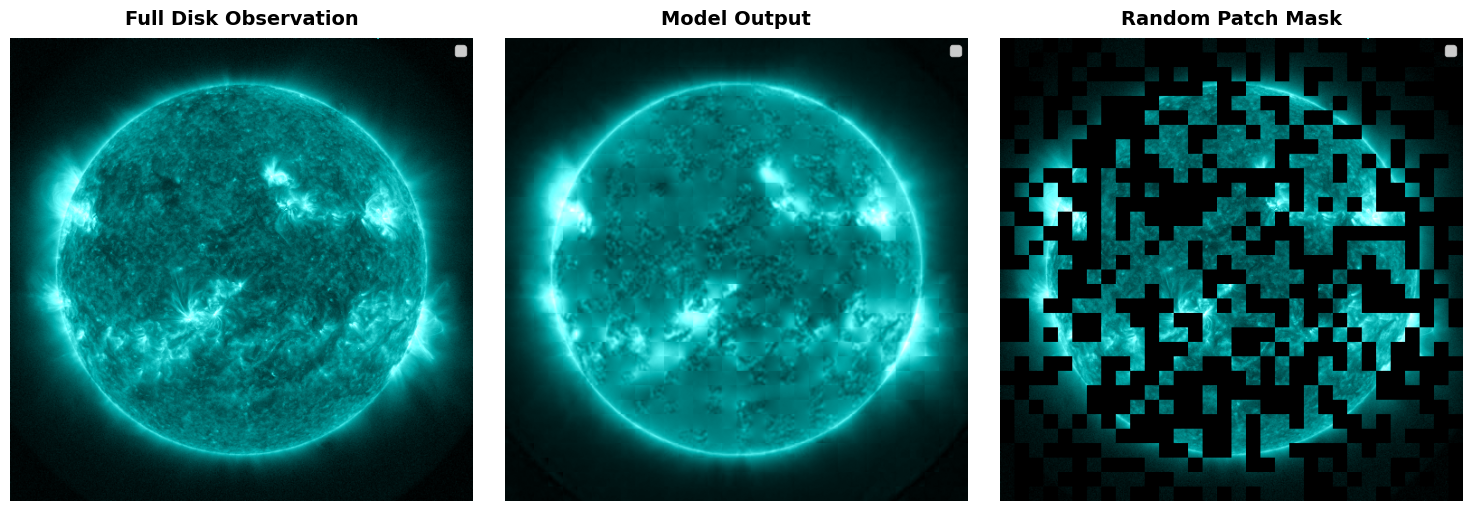

In [27]:
img_data = x_set[0, 0, 0, :, :]
vmin = img_data.min() # This represents true black
vmax = img_data.max()
masked_img = np.where(mask_full, vmin, img_data)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].imshow(img_data, cmap=cms[0])
axes[0].set_title('Full Disk Observation', fontsize=14, weight="bold", pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].legend()

axes[1].imshow(output[0][0, 0, 0, :, :], cmap=cms[0])
axes[1].set_title('Model Output', fontsize=14, weight="bold", pad=10)
axes[1].set_xlabel('')
axes[1].legend()

axes[2].imshow(masked_img, cmap=cms[0])
# axes[2].imshow(img_data, cmap=cms[0])
# axes[2].imshow(mask_full, cmap=cms[0], alpha=0.3)
axes[2].set_title('Random Patch Mask', fontsize=14, weight="bold", pad=10)
# axes[2].set_xlabel('')
axes[2].legend()

plt.tight_layout()

plt.savefig('check_mask.pdf', dpi=300, bbox_inches="tight")
plt.show()